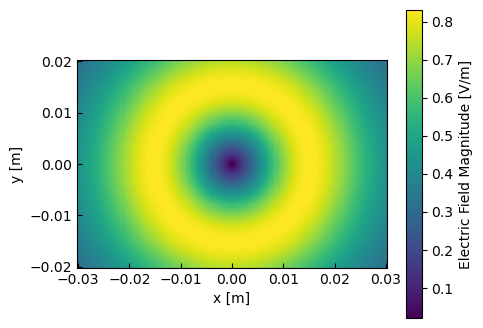

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipe

mu_0 = 4.0 * np.pi * 1e-7
eps0 = 8.8541878128e-12

def Aphi_coil(rho, z, a, I):

    rho = np.asarray(rho)
    A_phi = np.zeros_like(rho)
    
    mask = rho > 1e-12
    rho_m = rho[mask]
    
    denom = a**2 + rho_m**2 + z**2 + 2*a*rho_m
    k2 = 4*a*rho_m / denom
    
    K = ellipk(k2)
    E = ellipe(k2)
    
    factor = ((2 - k2)*K - 2*E) / k2
    
    A_phi[mask] = (mu_0 * I * a / np.pi) * factor / np.sqrt(denom)
    
    return A_phi

Nx, Ny = 150, 100
Lx, Ly = 0.06, 0.04

x = np.linspace(-Lx/2, Lx/2, Nx)
y = np.linspace(-Ly/2, Ly/2, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="xy")
R = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)

f = 1.0e6
omega = 2.0 * np.pi * f

I_coil = 1.0       
a_coil = 1.5e-2    
z0 = 1.0e-2        

Aphi = Aphi_coil(R, z0, a_coil, I_coil)

A1x = -Aphi * np.sin(Phi)
A1y =  Aphi * np.cos(Phi)

A1x[R < 1e-15] = 0.0
A1y[R < 1e-15] = 0.0

E1x = -1j * omega * A1x
E1y = -1j * omega * A1y

E1 = (E1x, E1y)
A1 = (A1x, A1y)

# E_1 is purely imaginary
# Field is out of phase with the current
E1x_imag = E1x.imag
E1y_imag = E1y.imag
E_mag = np.sqrt(E1x_imag**2 + E1y_imag**2)

fig, ax = plt.subplots(1, figsize=(5, 4))
im = ax.pcolormesh(X, Y, E_mag, shading='auto', cmap='viridis')
fig.colorbar(im, ax=ax, label="Electric Field Magnitude [V/m]")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.tick_params(direction="in")


In [ ]:
from scipy.signal import fftconvolve

sigma_healthy = 0.55   
sigma_anom = 0.2      

x0, y0 = 0.02, 0.00
w = 8.0e-3  
gauss = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2.0 * w**2))
sigma = sigma_healthy + (sigma_anom - sigma_healthy) * gauss
#eps_r = 80.0
#eps_sample = eps_r * eps0 # See later if this is optional at 1 MHz

#eps_map = eps_sample * np.ones_like(sigma)
#sigma_tilde = sigma + 1j * omega * eps_map
log_sigma_tilde = np.log(sigma)


dlogsig_dx = np.gradient(log_sigma_tilde, dx, axis=1)
dlogsig_dy = np.gradient(log_sigma_tilde, dy, axis=0)

# Dot product E1 . grad(ln(sigma))
rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)

# Assume thickness for integral
h_thickness = 0.01  

# Kernel of Green de Coulomb: 1 / |r - r'|
# Para fftconvolve, el kernel debe estar centrado en el origen
kx = np.arange(-Nx+1, Nx) * dx
ky = np.arange(-Ny+1, Ny) * dy
KX, KY = np.meshgrid(kx, ky, indexing="xy")


R_kernel = np.sqrt(KX**2 + KY**2 + (h_thickness/2.0)**2)
kernel_coulomb = 1.0 / R_kernel


V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy


dV2_dy, dV2_dx = np.gradient(V2, dy, dx)
delta_E2_x = -dV2_dx
delta_E2_y = -dV2_dy


E2_prime_x = E1x + delta_E2_x
E2_prime_y = E1y + delta_E2_y

E2_prime = (E2_prime_x, E2_prime_y)

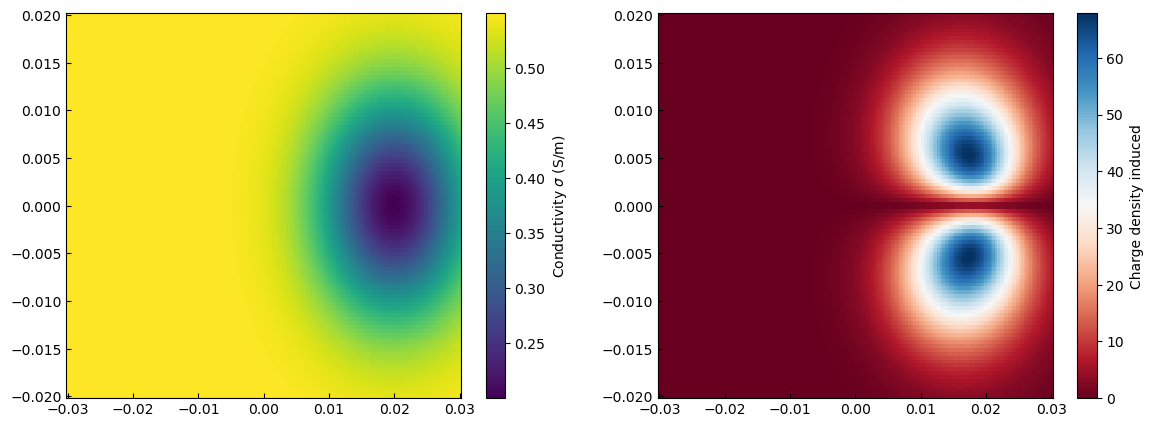

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.pcolormesh(X, Y, sigma, cmap='viridis', shading='auto')
fig.colorbar(im1, ax=ax1, label=r"Conductivity $\sigma$ (S/m)")
ax1.tick_params(direction="in")

im2 = ax2.pcolormesh(X, Y, np.abs(rho_eps0), cmap='RdBu', shading='auto')
fig.colorbar(im2, ax=ax2, label=r"Charge density induced")
ax2.tick_params(direction="in")

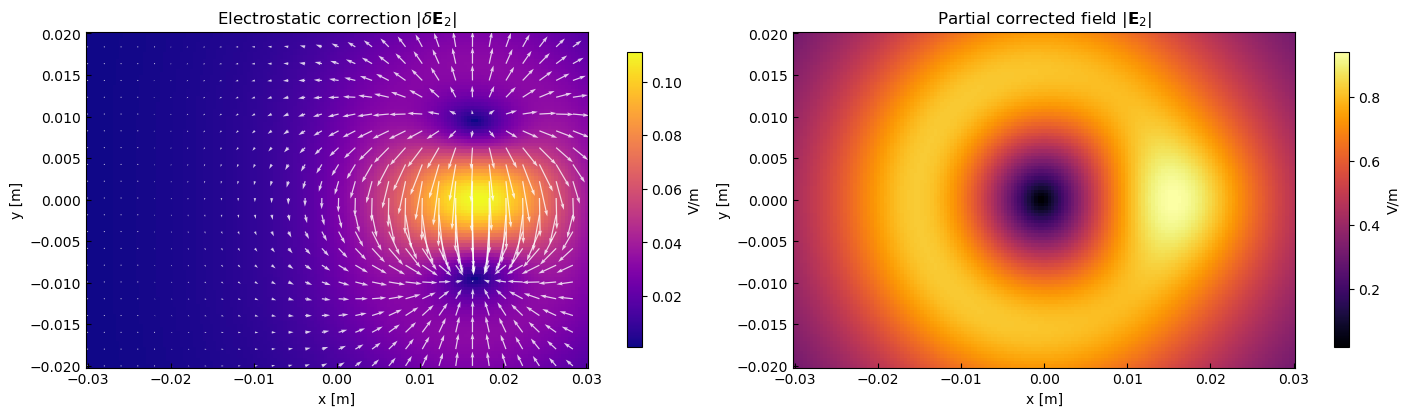

In [3]:
E1_mag = np.sqrt(np.abs(E1x)**2 + np.abs(E1y)**2)
delta_E2_mag = np.sqrt(np.abs(delta_E2_x)**2 + np.abs(delta_E2_y)**2)
E2_prime_mag = np.sqrt(np.abs(E2_prime_x)**2 + np.abs(E2_prime_y)**2)

# Extraemos las partes imaginarias para dibujar las líneas de campo
# (Como todo es imaginario puro, esto representa la amplitud del fasor físico)
dE2_x_im = np.imag(delta_E2_x)
dE2_y_im = np.imag(delta_E2_y)

fig, axs = plt.subplots(1,2, figsize=(14, 5), constrained_layout=True)


im1 = axs[0].pcolormesh(X , Y , delta_E2_mag, shading="auto", cmap="plasma")
axs[0].quiver(X[::5, ::5], Y[::5, ::5], dE2_x_im[::5, ::5], dE2_y_im[::5, ::5], 
              color='white', alpha=0.8, scale_units='xy')
axs[0].set_title(r'Electrostatic correction $|\delta\mathbf{E}_2|$')
axs[0].set_xlabel('x [m]')
axs[0].set_ylabel('y [m]')
axs[0].set_aspect("equal")
axs[0].tick_params(direction="in")
plt.colorbar(im1, ax=axs[0], shrink=0.6, label="V/m")

im2 = axs[1].pcolormesh(X , Y , E2_prime_mag, shading="auto", cmap="inferno")
axs[1].set_title(r'Partial corrected field $|\mathbf{E}_2|$')
axs[1].set_xlabel('x [m]')
axs[1].set_ylabel('y [m]')
axs[1].set_aspect("equal")
axs[1].tick_params(direction="in")
plt.colorbar(im2, ax=axs[1], shrink=0.6, label="V/m")


plt.show()

In [4]:
delta_rho3_eps0 = -(delta_E2_x * dlogsig_dx + delta_E2_y * dlogsig_dy)


delta_V3 = (h_thickness / (4.0 * np.pi)) * fftconvolve(delta_rho3_eps0, kernel_coulomb, mode='same') * dx * dy

dV3_dy, dV3_dx = np.gradient(delta_V3, dy, dx)
delta_E3_x = -dV3_dx
delta_E3_y = -dV3_dy

E3_partial_x = E1x + delta_E2_x + delta_E3_x
E3_partial_y = E1y + delta_E2_y + delta_E3_y

E3_partial = (E3_partial_x, E3_partial_y)

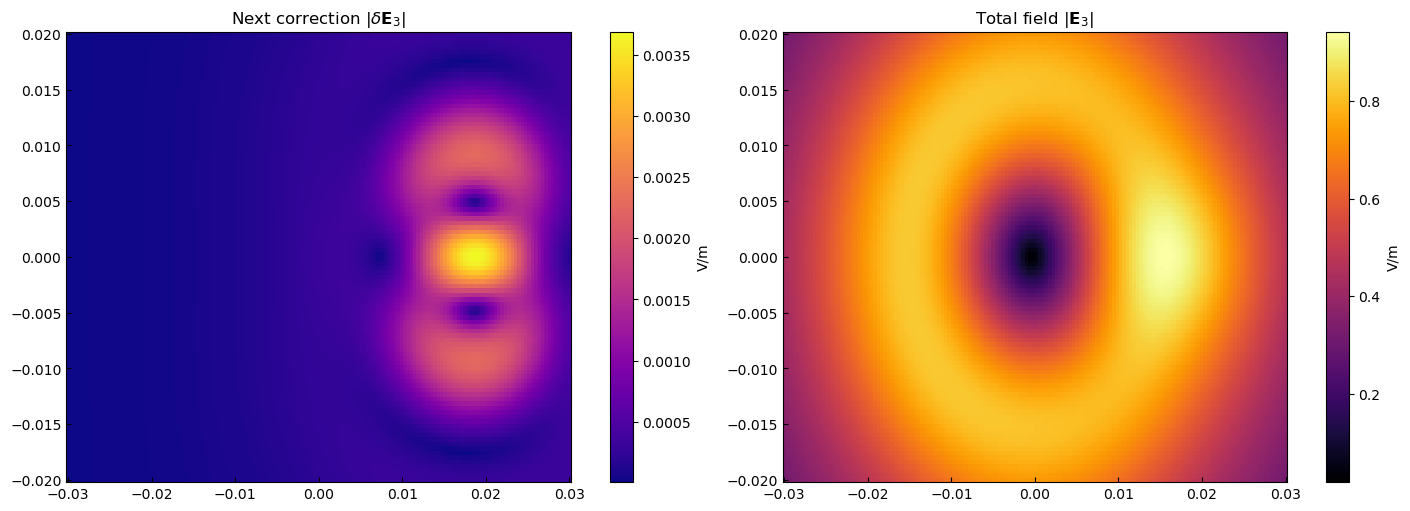

In [5]:
E3_total_x = E1x + delta_E2_x + delta_E3_x
E3_total_y = E1y + delta_E2_y + delta_E3_y

dE2_mag = np.sqrt(np.abs(delta_E2_x)**2 + np.abs(delta_E2_y)**2)
dE3_mag = np.sqrt(np.abs(delta_E3_x)**2 + np.abs(delta_E3_y)**2)
E3_tot_mag = np.sqrt(np.abs(E3_total_x)**2 + np.abs(E3_total_y)**2)

dE2_x_im, dE2_y_im = np.imag(delta_E2_x), np.imag(delta_E2_y)
dE3_x_im, dE3_y_im = np.imag(delta_E3_x), np.imag(delta_E3_y)
E3t_x_im, E3t_y_im = np.imag(E3_total_x), np.imag(E3_total_y)


fig, axs = plt.subplots(1,2, figsize=(14, 5), constrained_layout=True)
step = 6

im1 = axs[0].pcolormesh(X, Y, dE3_mag, shading="auto", cmap="plasma")
axs[0].set_title(r"Next correction $|\delta\mathbf{E}_3|$")
axs[0].tick_params(direction="in")
plt.colorbar(im1, ax=axs[0], label="V/m")

im2 = axs[1].pcolormesh(X, Y, E3_tot_mag, shading="auto", cmap="inferno")
axs[1].set_title(r"Total field $|\mathbf{E}_3|$")
axs[1].tick_params(direction="in")
plt.colorbar(im2, ax=axs[1], label="V/m")

plt.show()

### For any order we calculate the correction at order $n$

In [6]:
def compute_correction(deltaE_prev_x, deltaE_prev_y, dlogsig_dx, dlogsig_dy,
                       kernel_coulomb, h_thickness, dx, dy):
    delta_rho_eps0 = -(deltaE_prev_x * dlogsig_dx + deltaE_prev_y * dlogsig_dy)

    delta_V = (h_thickness / (4.0 * np.pi)) * fftconvolve(
        delta_rho_eps0, kernel_coulomb, mode='same'
    ) * dx * dy

    dV_dy, dV_dx = np.gradient(delta_V, dy, dx)
    deltaE_x = -dV_dx
    deltaE_y = -dV_dy

    return delta_rho_eps0, delta_V, deltaE_x, deltaE_y

def compute_perturbative_series(n_max, E1x, E1y, dlogsig_dx, dlogsig_dy,
                                kernel_coulomb, h_thickness, dx, dy):
    corrections = []
    total_x = E1x.copy()
    total_y = E1y.copy()

    delta_prev_x = E1x.copy()
    delta_prev_y = E1y.copy()

    for n in range(2, n_max + 1):
        delta_rho_eps0, delta_V, deltaE_x, deltaE_y = compute_correction(
            delta_prev_x, delta_prev_y,
            dlogsig_dx, dlogsig_dy,
            kernel_coulomb, h_thickness, dx, dy
        )

        total_x = total_x + deltaE_x
        total_y = total_y + deltaE_y

        corrections.append({
            "order": n,
            "rho_eps0": delta_rho_eps0,
            "V": delta_V,
            "deltaE_x": deltaE_x,
            "deltaE_y": deltaE_y,
            "total_x": total_x.copy(),
            "total_y": total_y.copy(),
            "deltaE_mag": np.sqrt(np.abs(deltaE_x)**2 + np.abs(deltaE_y)**2),
            "total_mag": np.sqrt(np.abs(total_x)**2 + np.abs(total_y)**2)
        })

        delta_prev_x = deltaE_x
        delta_prev_y = deltaE_y

    return corrections

In [7]:
corrections = compute_perturbative_series(
    n_max=10,
    E1x=E1x,
    E1y=E1y,
    dlogsig_dx=dlogsig_dx,
    dlogsig_dy=dlogsig_dy,
    kernel_coulomb=kernel_coulomb,
    h_thickness=h_thickness,
    dx=dx,
    dy=dy
)

corr3 = corrections[1]   # porque corrections[0] corresponde a n=2
delta_E3_x = corr3["deltaE_x"]
delta_E3_y = corr3["deltaE_y"]
E3_total_x = corr3["total_x"]
E3_total_y = corr3["total_y"]



In [8]:
def plot_order(corrections, k, X, Y, step=6):
    corr = corrections[k - 2]

    dEx_im = np.imag(corr["deltaE_x"])
    dEy_im = np.imag(corr["deltaE_y"])
    Etotx_im = np.imag(corr["total_x"])
    Etoty_im = np.imag(corr["total_y"])

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    im1 = axs[0].pcolormesh(X*1e3, Y*1e3, corr["deltaE_mag"], shading="auto", cmap="plasma")

    axs[0].set_title(rf"Correction $n={k}$ $|\delta\mathbf{{E}}_{k}|$")
    axs[0].set_xlabel('x [mm]')
    axs[0].set_ylabel('y [mm]')
    axs[0].set_aspect('equal')
    axs[0].tick_params(direction='in')
    plt.colorbar(im1, ax=axs[0], label='V/m', shrink=0.65, pad=0.02)

    im2 = axs[1].pcolormesh(X*1e3, Y*1e3, corr["total_mag"], shading="auto", cmap="inferno")

    axs[1].set_title(rf"Total field $|\mathbf{{E}}_{k}|$")
    axs[1].set_xlabel('x [mm]')
    axs[1].set_ylabel('y [mm]')
    axs[1].set_aspect('equal')
    axs[1].tick_params(direction='in')
    plt.colorbar(im2, ax=axs[1], label='V/m', shrink=0.65, pad=0.02)

    plt.show()

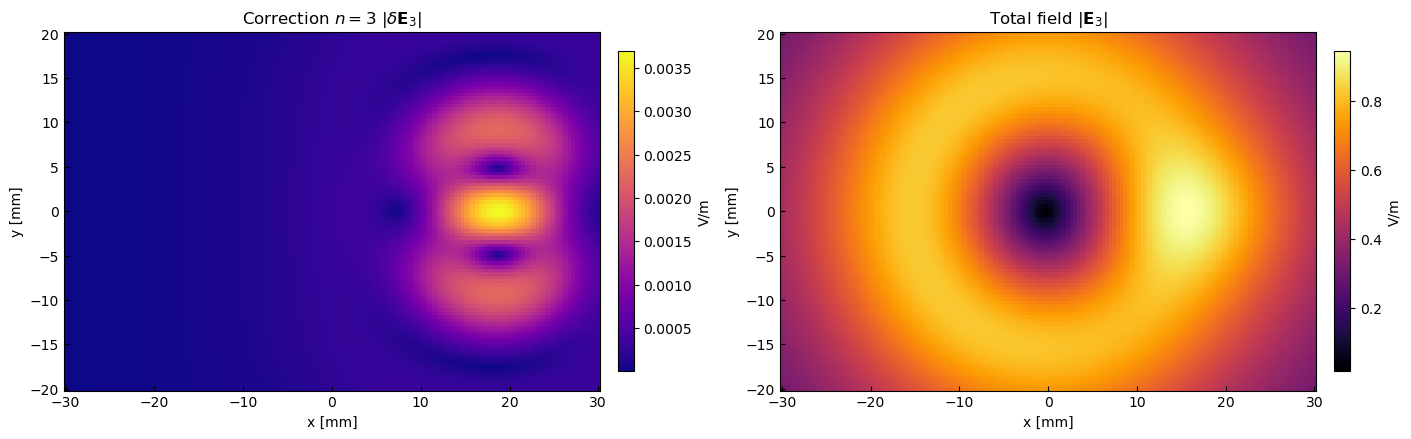

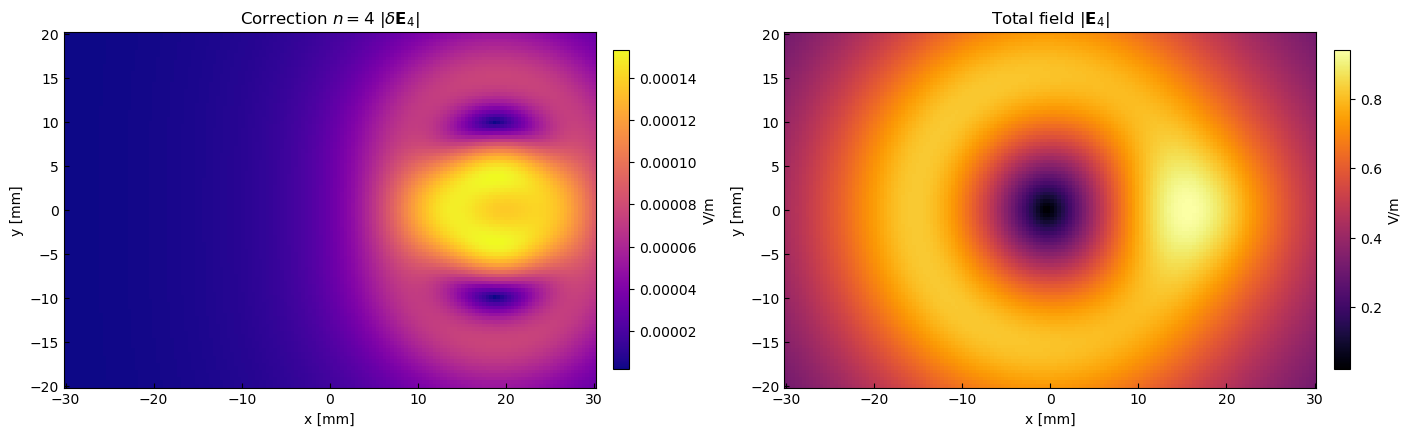

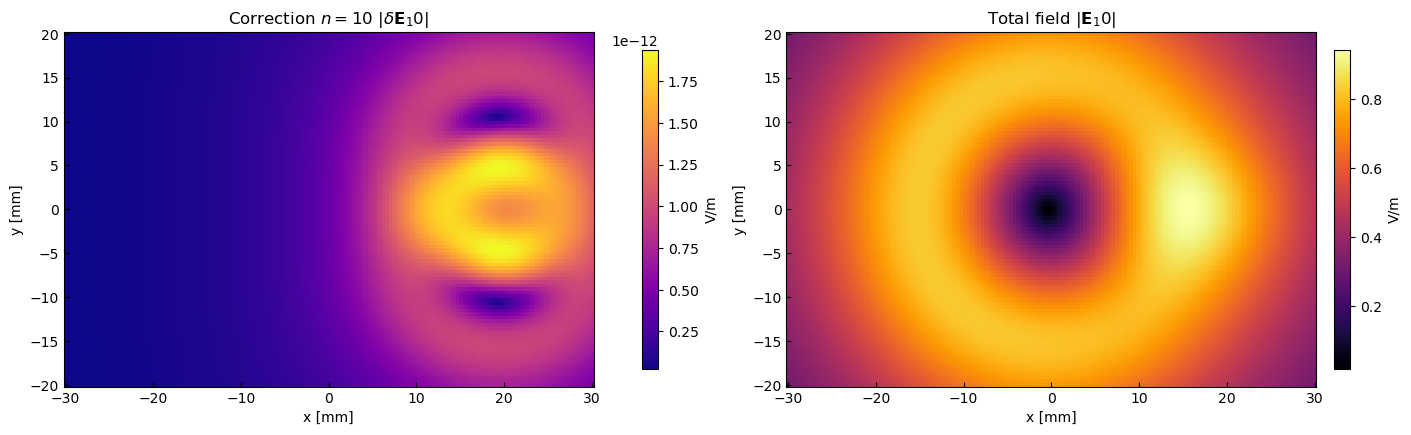

In [ ]:
plot_order(corrections, k=3, X=X, Y=Y, step=6)
plot_order(corrections, k=4, X=X, Y=Y, step=6)
plot_order(corrections, k=10, X=X, Y=Y, step=6)

In [9]:
import numpy as np
import pandas as pd

def compute_correction(deltaE_prev_x, deltaE_prev_y, dlogsig_dx, dlogsig_dy,
                       kernel_coulomb, h_thickness, dx, dy):
    delta_rho_eps0 = -(deltaE_prev_x * dlogsig_dx + deltaE_prev_y * dlogsig_dy)

    delta_V = (h_thickness / (4.0 * np.pi)) * fftconvolve(
        delta_rho_eps0, kernel_coulomb, mode='same'
    ) * dx * dy

    dV_dy, dV_dx = np.gradient(delta_V, dy, dx)
    deltaE_x = -dV_dx
    deltaE_y = -dV_dy

    return deltaE_x, deltaE_y


def convergence_table(n_max, E1x, E1y, dlogsig_dx, dlogsig_dy,
                      kernel_coulomb, h_thickness, dx, dy):
    rows = []

    E1_mag = np.sqrt(np.abs(E1x)**2 + np.abs(E1y)**2)
    E1_max = np.max(E1_mag)

    delta_prev_x = E1x.copy()
    delta_prev_y = E1y.copy()

    for n in range(2, n_max + 1):
        deltaE_x, deltaE_y = compute_correction(
            delta_prev_x, delta_prev_y,
            dlogsig_dx, dlogsig_dy,
            kernel_coulomb, h_thickness, dx, dy
        )

        deltaE_mag = np.sqrt(np.abs(deltaE_x)**2 + np.abs(deltaE_y)**2)
        deltaE_max = np.max(deltaE_mag)
        ratio = deltaE_max / E1_max

        rows.append({
            "order": n,
            "max_deltaE": deltaE_max,
            "max_E1": E1_max,
            "max_deltaE_over_max_E1": ratio
        })

        delta_prev_x = deltaE_x
        delta_prev_y = deltaE_y

    return pd.DataFrame(rows)

In [10]:
df_conv = convergence_table(
    n_max=8,
    E1x=E1x,
    E1y=E1y,
    dlogsig_dx=dlogsig_dx,
    dlogsig_dy=dlogsig_dy,
    kernel_coulomb=kernel_coulomb,
    h_thickness=h_thickness,
    dx=dx,
    dy=dy
)

print(df_conv)

   order    max_deltaE    max_E1  max_deltaE_over_max_E1
0      2  1.110950e-01  0.830193            1.338183e-01
1      3  3.687991e-03  0.830193            4.442329e-03
2      4  1.531156e-04  0.830193            1.844337e-04
3      5  8.376895e-06  0.830193            1.009030e-05
4      6  3.524001e-07  0.830193            4.244797e-07
5      7  2.076481e-08  0.830193            2.501202e-08
6      8  8.259366e-10  0.830193            9.948727e-10


In [ ]:
# df_conv.to_csv("convergence_table.csv", index=False)

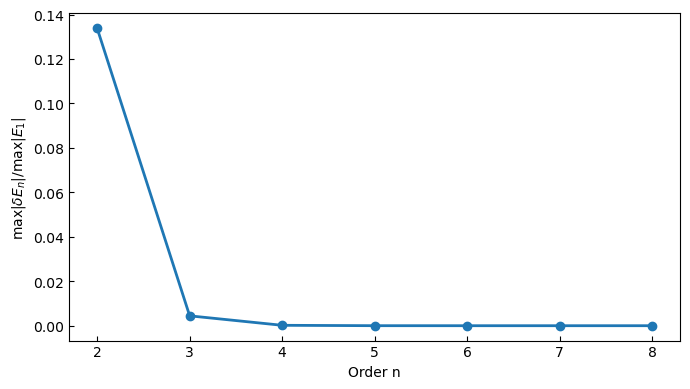

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    df_conv["order"],
    df_conv["max_deltaE_over_max_E1"],
    "o-",
    lw=2,
    ms=6
)

ax.set_xlabel("Order n")
ax.set_ylabel(r"$\max|\delta E_n| / \max|E_1|$")
#ax.set_yscale("log")
ax.set_xticks(df_conv["order"])
ax.minorticks_off()
ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

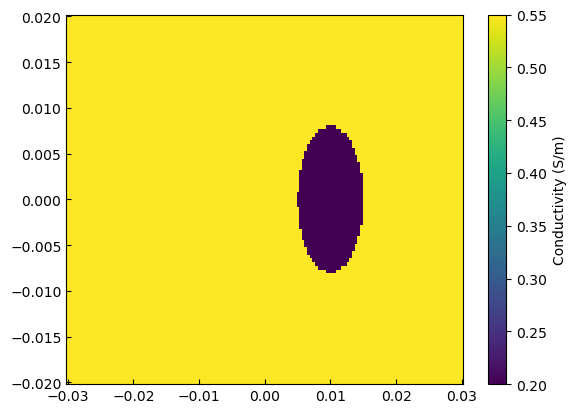

In [15]:
# Lets create now a region with anomalous conductivity (an ellipse)
# Healthy conductivity
sigma = np.ones((Ny, Nx)) * 0.55

# Ellipse parameters
x_center_ellipse = 1.0e-2
y_center_ellipse = 0.0
a_ellipse = 0.5e-2
b_ellipse = 0.8e-2

reduced_sigma = 0.2

ellipse_mask = ((X-x_center_ellipse)**2/a_ellipse**2 + ((Y-y_center_ellipse)**2/b_ellipse**2)) <= 1

sigma[ellipse_mask] = reduced_sigma

plt.pcolormesh(X, Y, sigma, shading="auto", cmap="viridis")
plt.colorbar(label="Conductivity (S/m)")
plt.tick_params(direction = "in")
plt.show()

/tmp/ipykernel_2405/4226821553.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


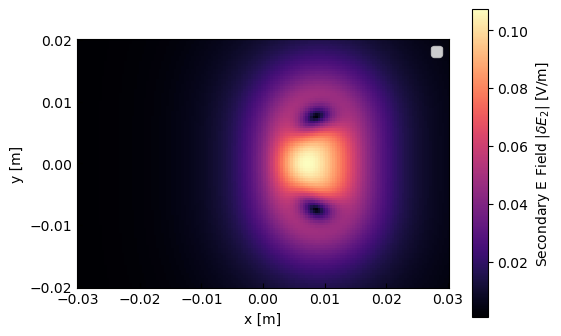

In [ ]:
N_theta = 300
theta = np.linspace(0, 2*np.pi, N_theta, endpoint=False)
dtheta = theta[1] - theta[0]

x_bound = x_center_ellipse + a_ellipse * np.cos(theta)
y_bound = y_center_ellipse + b_ellipse * np.sin(theta)

R_bound = np.sqrt(x_bound**2 + y_bound**2)
Phi_bound = np.arctan2(y_bound, x_bound)

Aphi_b = Aphi_coil(R_bound, z0, a_coil, I_coil)

A1x_b = -Aphi_b * np.sin(Phi_bound)
A1y_b =  Aphi_b * np.cos(Phi_bound)


E1x_b = -1j * omega * A1x_b
E1y_b = -1j * omega * A1y_b


# Tangent vector to the ellipse
tx = -a_ellipse * np.sin(theta)
ty =  b_ellipse * np.cos(theta)

# Normal vector to the ellipse
nx_un = ty
ny_un = -tx

# dl (magnitude of the tangent vector)
dl_dtheta = np.sqrt(tx**2 + ty**2)

# Normalizar el vector normal
nx = nx_un / dl_dtheta
ny = ny_un / dl_dtheta

# Real dl (normalized)
dl = dl_dtheta * dtheta

# Jump in conductivity
salto_ln = np.log(sigma_healthy) - np.log(reduced_sigma) 

# Superficial charge density: - E1 · n * jump
rho_l = -(E1x_b * nx + E1y_b * ny) * salto_ln

V2 = np.zeros_like(X, dtype=complex)

for i in range(N_theta):
    R_dist = np.sqrt((X - x_bound[i])**2 + (Y - y_bound[i])**2 + (h_thickness/2.0)**2)

    d_V2 = (h_thickness / (4.0 * np.pi)) * (rho_l[i] / R_dist) * dl[i]
    V2 += d_V2

dV2_dy, dV2_dx = np.gradient(V2, dy, dx)

delta_E2_x = -dV2_dx
delta_E2_y = -dV2_dy

E2_prime_x = E1x + delta_E2_x
E2_prime_y = E1y + delta_E2_y

delta_E_mag = np.sqrt(delta_E2_x.imag**2 + delta_E2_y.imag**2)

fig, ax = plt.subplots(1, figsize=(6, 4))
im = ax.pcolormesh(X, Y, delta_E_mag, shading='auto', cmap='magma')
fig.colorbar(im, ax=ax, label="Secondary E Field $|\\delta E_2|$ [V/m]")

ax.legend()

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.tick_params(direction="in")
plt.show()